# ROD Image Visualization Example

This notebook demonstrates how to read and visualize `.rodhypix` detector images from a CrysAlisPro experiment using the `cap_auto` package.

**Topics covered:**
- Extracting example data
- Reading native ROD image files without CAP
- Visualizing real-space images (grain snapshots)
- Visualizing diffraction frames
- Dynamic range adjustment using percentiles
- Accessing image metadata

**Audience:** CAP users with basic Python/Jupyter knowledge

## 1. Setup and Data Extraction

First, check if the example data is already extracted. If not, unzip it from `example_data/exp_11317.zip`.

In [13]:
import os
import zipfile
from pathlib import Path

# Navigate to repository root if needed
if Path.cwd().name == 'examples':
    os.chdir('..')

# Check if data already extracted
data_dir = Path('example_data/exp_11317')
zip_file = Path('example_data/exp_11317.zip')

if not data_dir.exists():
    if zip_file.exists():
        print(f"Extracting {zip_file}...")
        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            zip_ref.extractall('example_data')
        print(f"✓ Extracted to {data_dir}")
    else:
        raise FileNotFoundError(f"Neither {data_dir} nor {zip_file} found!")
else:
    print(f"✓ Data already extracted at {data_dir}")

✓ Data already extracted at example_data\exp_11317


In [14]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from cap_auto.rod_image_reader import RODImageReader, read_rod_image, get_rod_info
from glob import glob

print("✓ Imports successful")
print(f"✓ Found {len(list(data_dir.glob('*.rodhypix')))} .rodhypix files")

✓ Imports successful
✓ Found 6 .rodhypix files


## 2. Real-Space Image Visualization

Let's visualize the grain snapshots (real-space microscope images). These images need careful dynamic range adjustment to see features clearly.

**Key tip:** Use percentile-based scaling for real-space images to handle varying brightness levels.

✓ grain: range [-1, 260], using [-1, 213]
✓ preview: range [0, 1278], using [0, 1040]
✓ preview: range [0, 1278], using [0, 1040]


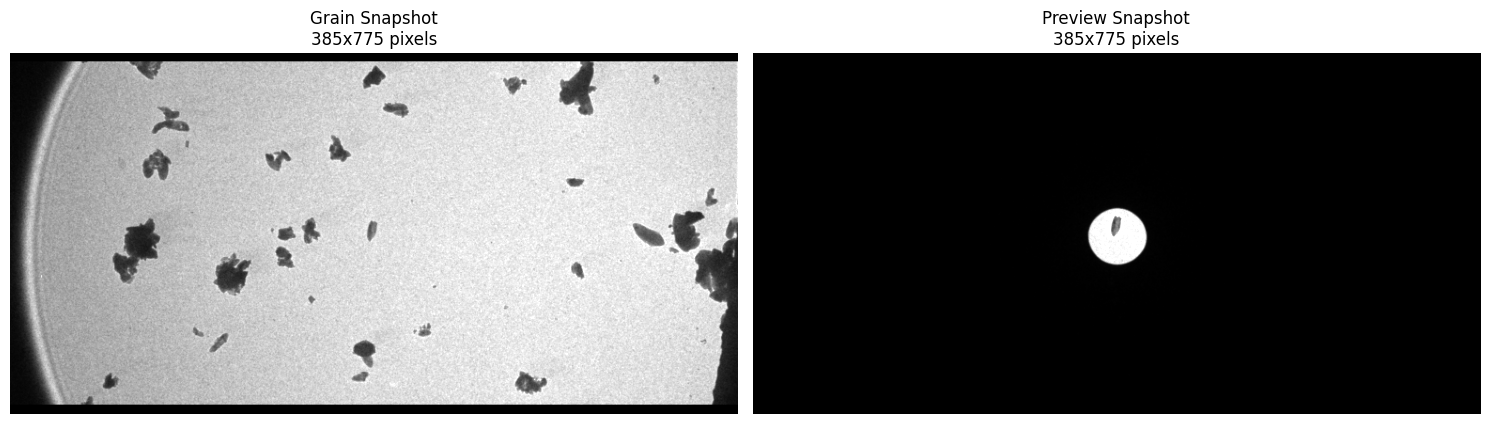

In [17]:
# Find grain snapshot images
grain_images = {
    'grain': 'exp_11317_microed_grain_snapshot.rodhypix',
    'preview': 'exp_11317_microed_preview_grain_snapshot.rodhypix'
}

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for idx, (name, filename) in enumerate(grain_images.items()):
    filepath = data_dir / filename
    
    if filepath.exists():
        # Read image
        reader = RODImageReader(filepath)
        image = reader.get_raw_data()
        
        # Set dynamic range using percentiles (exclude extreme values)
        vmin, vmax = np.percentile(image, [2, 99.5])
        
        # Display
        axes[idx].imshow(image, cmap='gray', vmin=vmin, vmax=vmax)
        axes[idx].set_title(f'{name.capitalize()} Snapshot\n{image.shape[0]}x{image.shape[1]} pixels')
        axes[idx].axis('off')
        
        print(f"✓ {name}: range [{image.min()}, {image.max()}], using [{vmin:.0f}, {vmax:.0f}]")
    else:
        axes[idx].text(0.5, 0.5, f'{filename}\nnot found', 
                       ha='center', va='center', transform=axes[idx].transAxes)
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 3. Diffraction Frame Visualization

Diffraction patterns have very different intensity distributions (strong central spots, weak high-resolution reflections).

**Key tips:**
- Use 0 as baseline and an appropriate percentile to see weak spots
- Try different colormaps (viridis, inferno) for diffraction

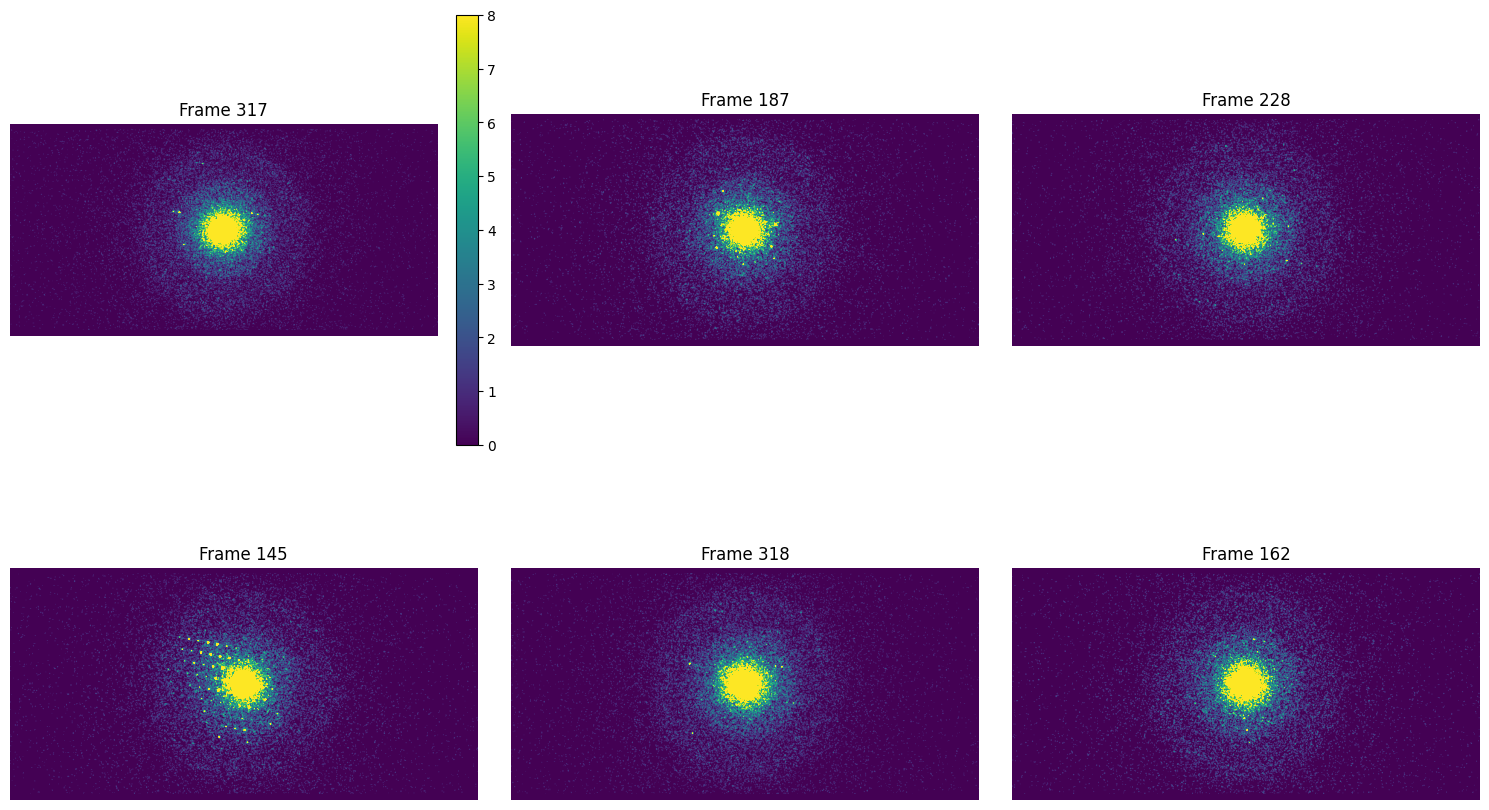

✓ Displayed 6 diffraction frames


In [18]:
# Find diffraction frames
frames_dir = data_dir / 'frames'
import random
frame_files = random.sample(list(frames_dir.glob('*.rodhypix')), 6)  # Random 6 frames

if len(frame_files) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, frame_file in enumerate(frame_files):
        # Read diffraction image
        image = read_rod_image(frame_file)
        
        # Tighter percentiles for diffraction
        vmin, vmax = 0, np.percentile(image, 99)
        
        # Display with viridis colormap
        im = axes[idx].imshow(image, cmap='viridis', vmin=vmin, vmax=vmax)
        axes[idx].set_title(f'Frame {frame_file.stem.split("_")[-1]}')
        axes[idx].axis('off')
        
        # Add colorbar to first subplot
        if idx == 0:
            plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Displayed {len(frame_files)} diffraction frames")
else:
    print("⚠ No diffraction frames found in frames/ directory")

## 4. Image Metadata

Extract and display experimental parameters from the image headers.

In [19]:
# Get metadata from a diffraction frame
if len(frame_files) > 0:
    reader = RODImageReader(frame_files[0])
    info = reader.get_header_info()
    
    print("Key Experimental Parameters:")
    print("=" * 50)
    print(f"Image shape: {reader.get_image_shape()}")
    print(f"Pixel size: {reader.get_pixel_size()[0]:.4f} x {reader.get_pixel_size()[1]:.4f} mm")
    print(f"Exposure time: {reader.get_exposure_time():.3f} s")
    print(f"Detector type: {info.get('detector_type', 'unknown')}")
    print(f"Gain: {info['gain']}")
    print(f"Distance: {info['distance_mm']:.2f} mm")
    print(f"Wavelength: {info['alpha1_wavelength']:.5f} Å")
    print(f"\nDecompression method: {reader.get_decompression_method()}")

Key Experimental Parameters:
Image shape: (385, 775)
Pixel size: 0.1000 x 0.1000 mm
Exposure time: 0.125 s
Detector type: 10
Gain: 1.0
Distance: 652.53 mm
Wavelength: 0.02510 Å

Decompression method: Python


## 5. Cleanup (Optional)

Uncomment and run this cell to remove the extracted data folder.

In [12]:
# import shutil
# 
# if data_dir.exists():
#     shutil.rmtree(data_dir)
#     print(f"✓ Deleted {data_dir}")
# else:
#     print(f"⚠ {data_dir} not found")